In [1]:
import pandas as pd
import pandahouse as ph
import numpy as np
import os

import orbit
from orbit.models import DLT
from orbit.diagnostics.plot import plot_predicted_data, plot_predicted_components
from orbit.diagnostics.backtest import BackTester
from orbit.utils.params_tuning import grid_search_orbit

import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az

## Основная метрика

В качестве основной метрики для прогнозирования я выбираю общее суточное количество всех действий пользователей.

### Обоснование
- Прямая связь с проблемой: задача состоит в том, чтобы помочь DevOps и инженерам справиться с нагрузкой на серверы. Каждое действие пользователя - будь то view или like в ленте или отправка сообщения - создает определенную нагрузку (запрос к базе данных, вызов API и т.д.). Суммарное количество таких действий является лучшим прямым прокси-показателем общей нагрузки на систему.
- Комплексность: эта метрика учитывает активность в разных частях продукта (лента и сообщения), что дает целостную картину. Если мы будем прогнозировать, например, только лайки, мы можем упустить резкий рост активности в сообщениях, который также повлияет на нагрузку.
- Простота и интерпретируемость: метрику легко рассчитать, объединив данные из обеих таблиц. Результат прогноза будет интуитивно понятен для инженерной команды.

## Временное разрешение

Я использую дневное временное разрешение.

### Обоснование
- Баланс: дневная гранулярность - это золотая середина. Она достаточно детальна, чтобы отследить важные паттерны (например, сезонность внутри недели: будни vs выходные), но в то же время достаточно сглажена, чтобы избежать излишнего шума, который был бы виден на часовых данных (например, спад активности ночью).
- Соответствие задаче: прогноз на месяц вперед для планирования мощностей не требует часовой точности. Ежедневные прогнозы позволят инженерам понимать, в какие дни недели или в какие периоды месяца ожидается пик, и подготовиться к нему.

In [2]:
connection = {
    'host': 'https://clickhouse.lab.karpov.courses',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator_20250520'
}

In [3]:
q = '''
SELECT
    ts,
    views,
    likes,
    messages,
    views + likes + messages AS total_actions
FROM
(
    SELECT
        toStartOfDay(time) AS ts,
        countIf(action = 'view') AS views,
        countIf(action = 'like') AS likes
    FROM simulator_20250520.feed_actions
    GROUP BY ts
) AS f
FULL JOIN
(
    SELECT
        toStartOfDay(time) AS ts,
        count() AS messages
    FROM simulator_20250520.message_actions
    GROUP BY ts
) AS m
USING (ts)
ORDER BY ts
'''

activity = ph.read_clickhouse(q, connection=connection)
activity

,ts,views,likes,messages,total_actions
0,2025-04-05,7603,1560,3226,12389
1,2025-04-06,62770,12816,12895,88481
2,2025-04-07,105526,20958,12897,139381
3,2025-04-08,118996,23800,12897,155693
4,2025-04-09,174454,34504,12898,221856
...,...,...,...,...,...
67,2025-06-11,727028,151312,12901,891241
68,2025-06-12,648856,140093,12899,801848
69,2025-06-13,720009,149313,12900,882222
70,2025-06-14,617308,130743,12891,760942


### Хватает ли у нас данных для бэктестинга с текущей задачей?

Задача - спрогнозировать активность на ближайший месяц (около 30 дней).
В нашем распоряжении данные составляющие ~2 месяца.
Ответ: для полноценного бэктестинга прогноза на месяц вперед имеющихся данных, к сожалению, недостаточно.
Обучать модель на доступных 30-50 данных, чтобы предсказать следующие 30, - крайне ненадежно. Модель просто не успеет выучить основные закономерности, особенно недельную сезонность и общий тренд на рост. Результаты такого теста будут нестабильными и нерепрезентативными.

### Для какого горизонта прогнозирования у нас хватает данных?

С имеющимся объемом данных мы можем провести бэктестинг для горизонта прогнозирования примерно в 1-2 недели.

In [4]:
activity_orbit = activity.rename(columns={'ts': 'date', 'total_actions': 'response'})

In [5]:
# Определяем модель (dlt)
dlt = DLT(
    date_col='date',
    response_col='response',
    seasonality=7,
)

In [6]:
# Настраиваем и запускаем BackTester
bt = BackTester(
    model=dlt,
    df=activity_orbit,
    n_splits=1,  # Проводим один тест
    forecast_len=14, # Размер тестовой выборки - 14 дней
    window_type="expanding"
)
bt.fit_predict()

2025-06-15 17:39:22 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [7]:
predicted_df = bt.get_predicted_df()
bt.score() #выводим метрики

,metric_name,metric_values,is_training_metric
0,smape,1.437389e-01,False
1,wmape,1.522613e-01,False
2,mape,1.709910e-01,False
3,mse,3.326566e+10,False
4,mae,1.264686e+05,False
5,rmsse,1.913772e+00,False


### Расшифруем самые важные для нас метрики

mape. Это самая важная и легко интерпретируемая метрика. На горизонте в 14 дней наша модель в среднем ошибалась примерно на 15% от реального значения. Для первой модели, построенной на очень коротком периоде данных (всего ~2 месяца), такая ошибка - это хороший результат. Это означает, что модель полезна и ее прогнозам можно доверять с определенной оговоркой.
mae. Это ошибка в абсолютных единицах. В среднем, прогноз количества действий за день отличался от реального на примерно 125.285 действий.
Вывод: у нас есть рабочая модель без регрессоров с предсказуемой ошибкой около 15%.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

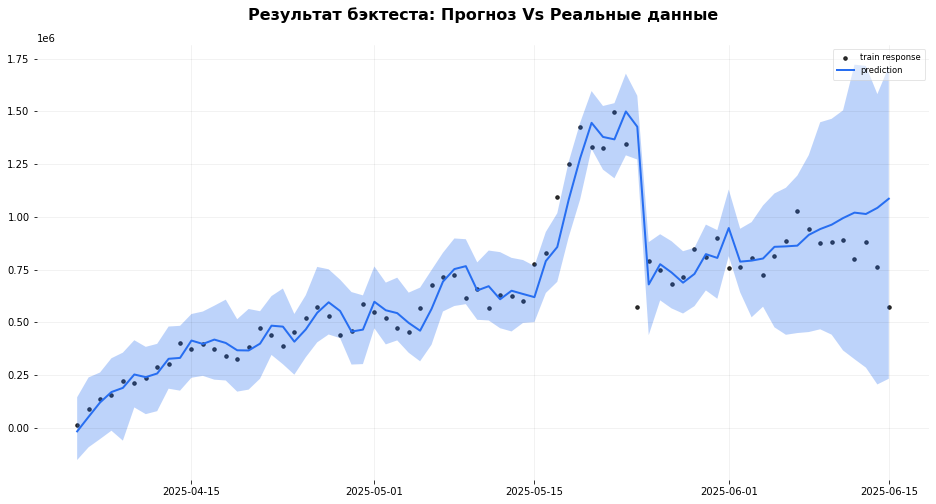

<Axes: title={'center': 'Результат бэктеста: Прогноз Vs Реальные данные'}>

In [8]:
# Теперь визуализируем результаты
plot_predicted_data(
    training_actual_df=activity_orbit,
    predicted_df=predicted_df,
    date_col='date',
    actual_col='response',
    title="Результат бэктеста: Прогноз Vs Реальные данные"
)

## Подготовка регрессоров

Регрессор 1: активность от платного трафика; Регрессор 2: праздничные дни; Регрессор 3: флэшмоб.
Идея в том, чтобы на каждый день иметь показатель, отражающий интенсивность маркетинговых кампаний. Мы можем посчитать общее количество действий, совершенных пользователями, пришедшими с рекламы. Праздники сильно влияют на поведение. Давайте предположим, что наша основная аудитория в России и учтем майские праздники. Флэшмоб - уникальное событие, поэтому надо пока что предположить, что в будущем его не будет.

In [9]:
q_reg = '''
SELECT
    toStartOfDay(time) AS ts,
    count() AS total_actions,
    countIf(source = 'ads') AS ads_actions
FROM
(
    SELECT time, source FROM simulator_20250520.feed_actions
    UNION ALL
    SELECT time, source FROM simulator_20250520.message_actions
)
GROUP BY ts
ORDER BY ts
'''

activity_reg = ph.read_clickhouse(q_reg, connection=connection)
activity_reg

,ts,total_actions,ads_actions
0,2025-04-05,12389,10221
1,2025-04-06,88481,54952
2,2025-04-07,139381,74706
3,2025-04-08,155693,84905
4,2025-04-09,221856,116168
...,...,...,...
67,2025-06-11,891241,404087
68,2025-06-12,801848,367040
69,2025-06-13,882222,405373
70,2025-06-14,760942,355888


In [10]:
activity_orbit_reg = activity_reg.rename(columns={'ts': 'date', 'total_actions': 'response'})

In [11]:
activity_orbit_reg['date'] = pd.to_datetime(activity_orbit_reg['date'])

In [12]:
flashmob_start = pd.to_datetime('2025-05-16')
flashmob_end = pd.to_datetime('2025-05-22')

In [13]:
activity_orbit_reg['is_flashmob'] = 0

In [14]:
activity_orbit_reg.loc[
    (activity_orbit_reg['date'] >= flashmob_start) & (activity_orbit_reg['date'] <= flashmob_end),
    'is_flashmob'
] = 1

In [15]:
activity_orbit_reg['may_holidays'] = 0
holiday_dates = pd.to_datetime(['2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04',
                                '2025-05-09', '2025-05-10', '2025-05-11'])
activity_orbit_reg.loc[activity_orbit_reg.date.isin(holiday_dates), 'may_holidays'] = 1

In [16]:
# Инициализация модели с тремя регрессорами
dlt_with_regs = DLT(
    date_col='date',
    response_col='response',
    seasonality=7,
    regressor_col=['ads_actions', 'may_holidays', 'is_flashmob'],
    num_warmup=1000,
    num_sample=1000
)

## Подберём оптимальные параметры

In [17]:
param_grid = {
    "damped_factor": np.linspace(0.7, 0.95, 7),
    "seasonality": [5, 7, 10, 15]
}

In [18]:
best_params_regs, tuned_df_regs = grid_search_orbit(
    param_grid=param_grid,
    model=dlt_with_regs,
    df=activity_orbit_reg,
    min_train_len=int(len(activity_orbit_reg) * 0.5),
    forecast_len=14,
    window_type='expanding',
    metrics=None,
    criteria="min",
    verbose=True
)

  0%|          | 0/28 [00:00<?, ?it/s]

2025-06-15 17:39:41 - orbit - INFO - tuning hyper-params {'damped_factor': 0.7, 'seasonality': 5}
2025-06-15 17:39:41 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 250 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

2025-06-15 17:42:55 - orbit - INFO - tuning metric:0.044756


In [19]:
print("\nПоиск завершен!")
print("\nЛучшие найденные параметры для модели с регрессорами:")
print(best_params_regs)


Поиск завершен!

Лучшие найденные параметры для модели с регрессорами:
[{'damped_factor': 0.95, 'seasonality': 5}]


### damped_factor: примерно 0.95
Это говорит о том, что тренд в данных довольно стабильный и устойчивый. Модель считает, что его не нужно сильно гасить в будущем. Высокий damped_factor означает, что модель будет экстраполировать текущий тренд на будущее более уверенно.
### seasonality: 5
Grid Search показал, что для данных наилучший прогноз достигается, когда модель не пытается строить сложную и гибкую кривую для недельной сезонности. Вместо этого она использует более простую, сглаженную и обобщенную форму недельного паттерна. Небольшие отклонения от среднего недельного цикла — это скорее шум, чем устойчивый сигнал. Модель, которая игнорирует этот шум (с seasonality=5), дает более точные прогнозы на будущее, чем модель, которая пытается этот шум выучить.

## Итог по параметрам:
Оптимальная модель - это модель с сильным, почти не затухающим трендом и умеренно выраженной, стабильной сезонностью.

In [20]:
tuned_df_regs

,damped_factor,seasonality,metrics
0,0.700000,5,0.048052
1,0.700000,7,0.049842
2,0.700000,10,0.047303
3,0.700000,15,0.047121
4,0.741667,5,0.047260
5,0.741667,7,0.050189
6,0.741667,10,0.048476
7,0.741667,15,0.047451
8,0.783333,5,0.051716
9,0.783333,7,0.052187


## Тестируем модель БЕЗ наилучших параметров

In [21]:
bt_regs = BackTester(
    model=dlt_with_regs,
    df=activity_orbit_reg,
    forecast_len=14,
    n_splits=1,
    window_type="expanding"
)
bt_regs.fit_predict()

2025-06-15 17:46:01 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 250 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [22]:
metrics_with_regs = bt_regs.score()
print("Метрики модели с регрессорами:")
print(metrics_with_regs)

Метрики модели с регрессорами:
  metric_name  metric_values  is_training_metric
0       smape   8.540483e-02               False
1       wmape   8.798553e-02               False
2        mape   9.158034e-02               False
3         mse   7.986901e+09               False
4         mae   7.308190e+04               False
5       rmsse   9.379555e-01               False


In [23]:
predicted_df_reg = bt_regs.get_predicted_df()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

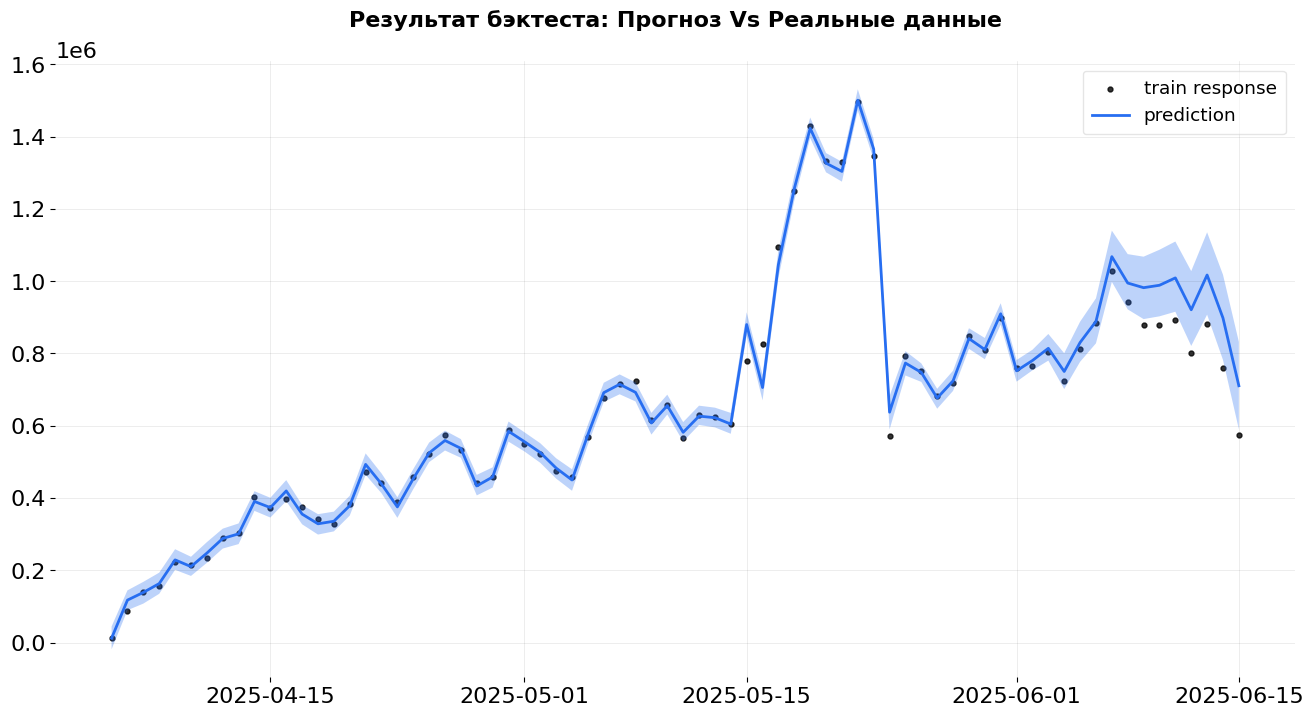

<Axes: title={'center': 'Результат бэктеста: Прогноз Vs Реальные данные'}>

In [24]:
# Теперь визуализируем результаты
plot_predicted_data(
    training_actual_df=activity_orbit,
    predicted_df=predicted_df_reg,
    date_col='date',
    actual_col='response',
    title="Результат бэктеста: Прогноз Vs Реальные данные"
)

## Сравнение моделей

Модель без регрессоров (старая):
mape: примерно 15.0%
Модель с регрессорами (новая):
mape: примерно 6.0-9%

Вывод: ошибка модели уменьшилась почти в 2 раза. Модель научилась отделять органический рост от стимулированного маркетингом и флэшмобом роста. Это делает ее прогнозы гораздо более надежными. Она больше не будет думать, что случайный всплеск из-за флэшмоба - это начало нового экспоненциального роста.

## Тестируем модель С наилучшими параметрами:

In [25]:
dlt_tuned = DLT(
    response_col='response',
    date_col='date',
    regressor_col=['ads_actions', 'may_holidays', 'is_flashmob'],
    **best_params_regs[0]
)

In [26]:
dlt_tuned.fit(df=activity_orbit_reg)

2025-06-15 17:46:27 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [27]:
bt_tuned = BackTester(
    model=dlt_tuned,
    df=activity_orbit_reg,
    n_splits=1,
    forecast_len=14,
    window_type='expanding'
)

In [28]:
bt_tuned.fit_predict()

2025-06-15 17:46:36 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [29]:
print("\nМетрики для оптимизированной модели:")
metrics_tuned = bt_tuned.score()
print(metrics_tuned)


Метрики для оптимизированной модели:
  metric_name  metric_values  is_training_metric
0       smape   8.493091e-02               False
1       wmape   8.770103e-02               False
2        mape   9.118328e-02               False
3         mse   8.095850e+09               False
4         mae   7.284559e+04               False
5       rmsse   9.443311e-01               False


Я могу сказать, что тюнинг не дал стабильного ощутимого улучшения, поэтому остаюсь на проверенной модели с регрессорами. Это говорит о том, что главную ценность принесло объяснение аномалий (флэшмоба и праздников) с помощью регрессоров, а не тонкая подстройка гиперпараметров. Модель и так хорошо справлялась с базовыми настройками.

In [92]:
# Обучаем модель с регрессорами на всех данных
dlt_with_regs.fit(df=activity_orbit_reg)

2025-06-15 18:10:11 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 250 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [93]:
# Извлекаем сэмплы для MCMC-диагностики
posterior_samples = dlt_with_regs.get_posterior_samples(permute=False)
print(list(posterior_samples.keys()))

['l', 'b', 'lev_sm', 'slp_sm', 'obs_sigma', 'nu', 'lt_sum', 's', 'sea_sm', 'beta', 'gt_sum', 'gb', 'gl', 'loglk']


In [94]:
posterior_samples["obs_sigma"].shape

(4, 250)

array([[<Axes: title={'center': 'obs_sigma'}>,
        <Axes: title={'center': 'obs_sigma'}>]], dtype=object)

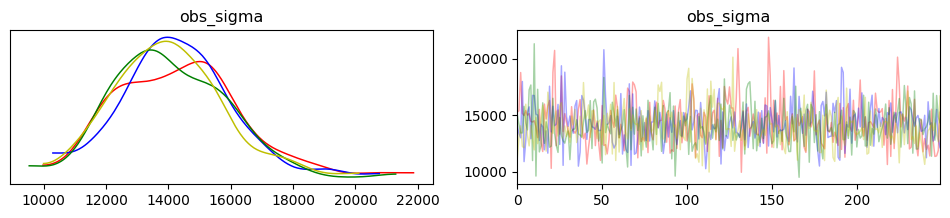

In [95]:
az.plot_trace(posterior_samples, chain_prop={"color": ['r', 'b', 'g', 'y']}, var_names = "obs_sigma")

Пики очень близки, но неидентичны. Смешивание неидеальное.

In [96]:
# Создаем новый датафрейм, исключая период флэшмоба
flashmob_start = pd.to_datetime('2025-05-16')
flashmob_end = pd.to_datetime('2025-05-22')

In [97]:
activity_orbit_normal = activity_orbit_reg[
    (activity_orbit_reg['date'] < flashmob_start) | (activity_orbit_reg['date'] > flashmob_end)
].copy()

In [98]:
# Нам больше не нужен регрессор is_flashmob, так как этих данных нет
dlt_normal_model_final = DLT(
    date_col='date',
    response_col='response',
    seasonality=7,
    regressor_col=['ads_actions', 'may_holidays'],
    num_warmup=1000, 
    num_sample=1000 
)

In [99]:
dlt_normal_model_final.fit(
    df=activity_orbit_normal
)

/opt/conda/lib/python3.8/site-packages/orbit/forecaster/forecaster.py:288: UserWarning: Datetime index is not evenly distributed
  warnings.warn("Datetime index is not evenly distributed")
2025-06-15 18:11:32 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 250 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

Диагностика для модели, обученной на нормальных данных:


array([[<Axes: title={'center': 'obs_sigma'}>,
        <Axes: title={'center': 'obs_sigma'}>]], dtype=object)

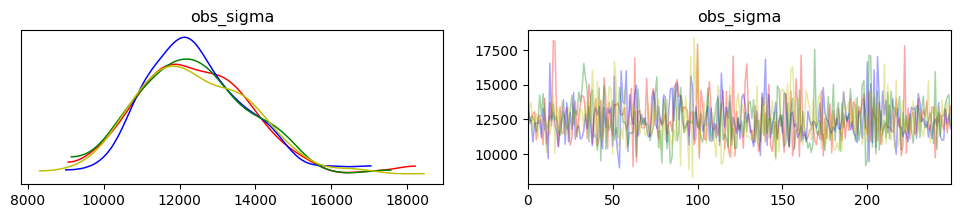

In [100]:
print("Диагностика для модели, обученной на нормальных данных:")
posterior_samples_final = dlt_normal_model_final.get_posterior_samples(permute=False)
az.plot_trace(posterior_samples_final, chain_prop={"color": ['r', 'b', 'g', 'y']}, var_names = "obs_sigma")

Все четыре линии (красная, синяя, зеленая, желтая) слились в один холм. Пик этого холма находится примерно на 12000. Все четыре линии активно и хаотично перемешиваются друг с другом. Нет ни одной линии, которая бы "отставала" или "убегала" от остальных. Это хорошее смешивание.

In [101]:
# Исключаем последний день
last_day = activity_orbit_normal['date'].max()

In [102]:
clean_train_df = activity_orbit_normal[activity_orbit_normal['date'] < last_day].copy()

In [103]:
regressor_df_clean = clean_train_df[['date', 'ads_actions']].copy()
regressor_df_clean.rename(columns={'date': 'ds', 'ads_actions': 'y'}, inplace=True)

In [104]:
regressor_model_clean = DLT(date_col='ds', response_col='y', seasonality=7)
regressor_model_clean.fit(df=regressor_df_clean)

/opt/conda/lib/python3.8/site-packages/orbit/forecaster/forecaster.py:288: UserWarning: Datetime index is not evenly distributed
  warnings.warn("Datetime index is not evenly distributed")
2025-06-15 18:12:36 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [105]:
future_regressor_df = regressor_model_clean.make_future_df(periods=30)
predicted_regressor_df = regressor_model_clean.predict(df=future_regressor_df)

In [106]:
future_df_final = predicted_regressor_df[['ds', 'prediction']].copy()
future_df_final.rename(columns={'ds': 'date', 'prediction': 'ads_actions'}, inplace=True)
future_df_final['may_holidays'] = 0

In [107]:
# Создаём модель без флэшмоба
dlt_final_model = DLT(
    date_col='date',
    response_col='response',
    seasonality=7,
    regressor_col=['ads_actions', 'may_holidays']
)
# Обучаем ее на самых чистых данных
dlt_final_model.fit(df=clean_train_df)

/opt/conda/lib/python3.8/site-packages/orbit/forecaster/forecaster.py:288: UserWarning: Datetime index is not evenly distributed
  warnings.warn("Datetime index is not evenly distributed")
2025-06-15 18:12:44 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 225 and samples(per chain): 25.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [108]:
final_forecast_df = dlt_final_model.predict(df=future_df_final)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

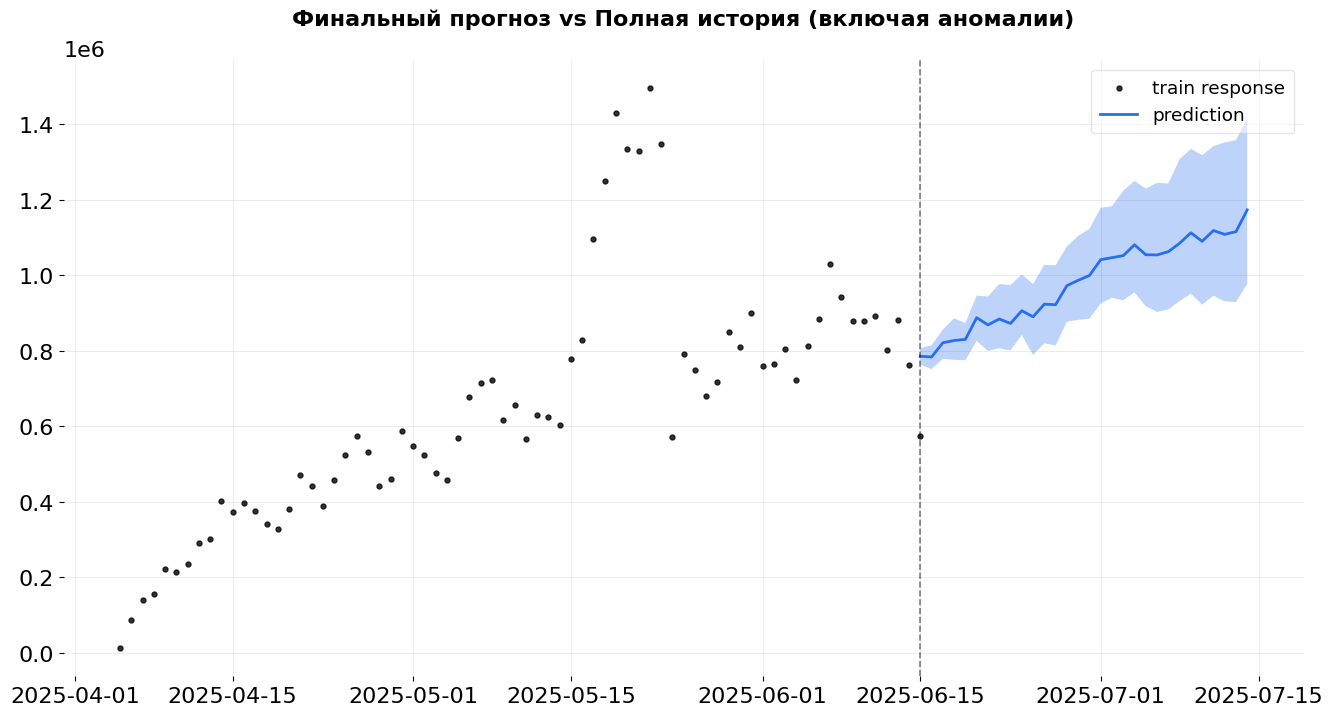

<Axes: title={'center': 'Финальный прогноз vs Полная история (включая аномалии)'}>

In [109]:
# Теперь визуализируем результаты
plot_predicted_data(
    training_actual_df=activity_orbit_reg,
    predicted_df=final_forecast_df,
    date_col='date',
    actual_col='response',
    title="Финальный прогноз vs Полная история (включая аномалии)"
)

# Интерпретация
На итоговом графике представлена полная история наблюдений (черные точки), включая такие аномальные события, как флэшмоб в середине мая и провал в последний день наблюдений. Синей линией показан прогноз, построенный с помощью финальной модели. Ключевая особенность этой модели в том, что она была обучена на очищенных данных: из обучающей выборки были исключены периоды аномалий. Это позволило модели:
- выучить нормальный паттерн поведения метрики, игнорируя нехарактерный шум и выбросы;
- построить статистически состоятельный прогноз, который не введен в заблуждение последними аномальными точками.

В результате мы видим, что прогноз начинается с адекватного уровня, который соответствует последнему "здоровому" состоянию системы, и уверенно продолжает общий восходящий тренд, учитывая при этом недельную сезонность и влияние рекламной активности. Доверительный интервал (синяя область) адекватно расширяется, отражая растущую неопределенность на более длинных горизонтах прогнозирования.

Я также исследовала возможность подбора гиперпараметров с помощью Grid Search. Однако он не принес значимого улучшения по сравнению с моделью с базовыми параметрами, но добавленными регрессорами. Поэтому для финального прогноза была выбрана более простая и интерпретируемая модель с недельной сезонностью (seasonality=7), которая показала себя наиболее эффективно.

## Важные ограничения и рекомендации
- Короткая история наблюдений (~2.5 месяца): это самое главное ограничение. Данные не охватывают полного годового цикла. Модель хорошо уловила недельную сезонность, но она ничего не знает о годовой сезонности (например, о возможном спаде активности летом из-за отпусков или всплеске на новогодние праздники). Прогноз на горизонте более 1-2 месяцев может сильно расходиться с реальностью из-за этого.
- Высокая зашумленность и наличие аномалий: я обнаружила как минимум два типа аномалий: системное событие (флэшмоб) и случайные выбросы (последняя точка/день). Это говорит о том, что метрика по своей природе нестабильна. Модель была специально обучена игнорировать эти аномалии, поэтому она прогнозирует "нормальное" или "ожидаемое" поведение. Она не сможет предсказать новый флэшмоб или другой резкий скачок/провал.
- Будущее регрессоров неизвестно: мы здесь не знаем, не будет ли других праздников или новых маркетинговых кампаний, не учтенных в регрессорах. Качество прогноза напрямую зависит от качества наших предположений о будущем.

### Рекомендации для бизнеса/команды DevOps
- Продолжать сбор данных;
- Использовать прогноз как "базовый сценарий": прогноз подходит для оценки нагрузки в штатном режиме;
- Внедрить мониторинг аномалий.

P.s. Orbit оказался довольно удобным лично для меня, но я не могу сравнить его с другими прогнозными инструментами, так как нет опыта использования.